<a href="https://colab.research.google.com/github/ansaganakhat/project-1/blob/main/notebook3_word2vec.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="background: linear-gradient(135deg, #4a148c 0%, #6a1b9a 50%, #7b1fa2 100%); padding: 40px 30px; border-radius: 12px; margin-bottom: 30px;">
  <h1 style="color:#ffffff; font-size:2.2em; font-weight:700; margin:0 0 10px 0;">Зертханалық Жұмыс 3</h1>
  <h2 style="color:#e1bee7; font-size:1.4em; font-weight:400; margin:0 0 16px 0;">Сөздердің Векторлық Көріністері — Word2Vec және GloVe</h2>
  <p style="color:#f3e5f5; font-size:1em; margin:0;">Word Embeddings · Cosine Similarity · Аналогия · 2D Визуализация · Семантикалық Кеңістік</p>
</div>

## Кіріспе

BoW жəне TF-IDF сөздерді бір-бірінен тəуелсіз, сирек (sparse) векторлар ретінде береді. Бұл əдіс семантикалық байланысты түсінбейді: `king` мен `queen` векторлары бір-бірінен алыс болады.

**Word2Vec** (2013, Google) — сөздерді тығыз (dense) векторлар кеңістігіне орналастырады. Семантикалық ұқсас сөздер кеңістікте жақын орналасады. Атақты мысал:

```
king - man + woman ≈ queen
```

**GloVe** (Global Vectors, 2014, Stanford) — жаһандық бірге кездесу статистикасын пайдаланады.

Бұл зертханада алдын ала үйретілген GloVe векторларын жүктеп, олармен тікелей жұмыс жасайсыз.

## Оқу Мақсаттары

- Word embedding-тің семантикалық кеңістік ретіндегі мəнін түсінесіз
- Косинустік ұқсастықты (cosine similarity) формула бойынша есептей аласыз
- GloVe векторлары арқылы ең ұқсас сөздерді таба аласыз
- Сөздік аналогия тапсырмасын (king - man + woman = ?) шеше аласыз
- PCA арқылы embedding-ті 2D-де визуализациялай аласыз
- Keras Embedding қабатымен жұмыс жасай аласыз

**Болжалды орындалу уақыты: 20 минут**

## 1-бөлім: Кітапханаларды Импорттау

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
import tensorflow as tf
from tensorflow.keras import layers
import warnings
warnings.filterwarnings('ignore')

print("Кітапханалар жүктелді.")

Кітапханалар жүктелді.


In [3]:
# ============================================================
### TODO ###
# numpy жəне sklearn нұсқаларын шығарыңыз.
# ============================================================
import sklearn
print("NumPy:", np.__version__)
print("sklearn:", sklearn.__version__)

NumPy: 2.0.2
sklearn: 1.6.1


## 2-бөлім: GloVe Векторларын Жүктеу

GloVe векторлары алдын ала үйретілген — Wikipedia + Gigaword корпусы (6 млрд токен). Бізге 50 өлшемді нұсқа керек. Желі болмаса — векторларды синтетикалық жасаймыз.

In [4]:
import os, urllib.request

# GloVe-тің кіші тест жинағын жасаймыз (нақты GloVe жүктеу орнына)
# Нақты жобада: https://nlp.stanford.edu/data/glove.6B.zip

# 200+ жиі қолданылатын сөз үшін 50-өлшемді псевдо-векторлар
np.random.seed(42)

EMBED_DIM = 50

# Семантикалық топтар — жақын сөздерді кластерлейміз
semantic_groups = {
    'royalty':   ['king', 'queen', 'prince', 'princess', 'royal', 'throne', 'crown'],
    'gender':    ['man', 'woman', 'boy', 'girl', 'male', 'female', 'he', 'she'],
    'science':   ['physics', 'chemistry', 'biology', 'mathematics', 'science', 'research'],
    'countries': ['france', 'germany', 'spain', 'italy', 'england', 'japan', 'china'],
    'capitals':  ['paris', 'berlin', 'madrid', 'rome', 'london', 'tokyo', 'beijing'],
    'animals':   ['cat', 'dog', 'horse', 'bird', 'fish', 'lion', 'tiger'],
    'food':      ['bread', 'meat', 'rice', 'pasta', 'soup', 'fruit', 'vegetable'],
    'tech':      ['computer', 'software', 'hardware', 'internet', 'algorithm', 'data'],
    'actions':   ['run', 'walk', 'swim', 'fly', 'jump', 'eat', 'sleep'],
    'numbers':   ['one', 'two', 'three', 'four', 'five', 'six', 'seven'],
}

word2vec = {}
group_centers = {}  # əр топтың центр векторы

for group, words in semantic_groups.items():
    center = np.random.randn(EMBED_DIM)
    group_centers[group] = center
    for word in words:
        # Центрге жақын, бірақ өзіндік шуы бар вектор
        word2vec[word] = center + np.random.randn(EMBED_DIM) * 0.3

# Жыныс осін анықтаймыз: man - woman
gender_axis = word2vec['man'] - word2vec['woman']
# Роялти осі: king - queen де жыныс осімен сəйкес болу керек
word2vec['king']  = word2vec['queen'] + gender_axis * 0.8
word2vec['prince']= word2vec['princess'] + gender_axis * 0.8

# Ел-астана байланысы
capital_offset = group_centers['capitals'] - group_centers['countries']
for country, capital in zip(
    ['france','germany','spain','italy','england','japan','china'],
    ['paris', 'berlin','madrid','rome', 'london','tokyo','beijing']
):
    word2vec[capital] = word2vec[country] + capital_offset + np.random.randn(EMBED_DIM)*0.1

vocab = sorted(word2vec.keys())
print(f"Жүктелген vocabulary: {len(vocab)} сөз")
print(f"Embedding өлшемі:     {EMBED_DIM}")
print(f"Мысал сөздер: {vocab[:10]}")

Жүктелген vocabulary: 69 сөз
Embedding өлшемі:     50
Мысал сөздер: ['algorithm', 'beijing', 'berlin', 'biology', 'bird', 'boy', 'bread', 'cat', 'chemistry', 'china']


## 3-бөлім: Косинустық Ұқсастық

In [5]:
def cosine_sim(v1, v2):
    """
    Екі вектордың косинустық ұқсастығын есептейді.
    cos(θ) = (v1 · v2) / (||v1|| × ||v2||)
    Мəн диапазоны: [-1, 1]
    """
    dot    = np.dot(v1, v2)
    norm1  = np.linalg.norm(v1)
    norm2  = np.linalg.norm(v2)
    return dot / (norm1 * norm2 + 1e-10)

print("cosine_sim() функциясы анықталды.")

cosine_sim() функциясы анықталды.


In [6]:
# ============================================================
### TODO ###
# Төмендегі сөз жұптарының косинустық ұқсастықтарын есептеңіз:
#   ('king', 'queen'), ('king', 'man'), ('cat', 'dog'),
#   ('france', 'paris'), ('computer', 'biology')
# Нəтижелерді жоғарыдан төменге қарай реттеп шығарыңыз.
# ============================================================
word_pairs = [
    ('king',    'queen'),
    ('king',    'man'),
    ('cat',     'dog'),
    ('france',  'paris'),
    ('computer','biology'),
]

similarities = []
for w1, w2 in word_pairs:
    sim = cosine_sim(word2vec[w1], word2vec[w2])   # w1, w2
    similarities.append((w1, w2, sim))

similarities.sort(key=lambda x: x[2], reverse=True)
print(f"{'Сөз 1':<12} {'Сөз 2':<12} {'Косинус':<10}")
print("-" * 36)
for w1, w2, sim in similarities:
    print(f"{w1:<12} {w2:<12} {sim:.4f}")

Сөз 1        Сөз 2        Косинус   
------------------------------------
king         queen        0.9433
cat          dog          0.9329
king         man          0.0800
france       paris        0.0608
computer     biology      -0.0856


In [7]:
def most_similar(word, word2vec, top_n=5, exclude=None):
    """
    Берілген сөзге ең ұқсас top_n сөзді қайтарады.
    """
    if word not in word2vec:
        return []
    exclude = set(exclude or [])
    exclude.add(word)

    vec = word2vec[word]
    scores = [
        (w, cosine_sim(vec, word2vec[w]))
        for w in word2vec if w not in exclude
    ]
    return sorted(scores, key=lambda x: x[1], reverse=True)[:top_n]

print("most_similar() функциясы анықталды.")

most_similar() функциясы анықталды.


In [8]:
# ============================================================
### TODO ###
# most_similar() функциясын 3 əртүрлі сөзге қолданыңыз:
# 'king', 'paris', 'science' сөздерінің ең ұқсас 5 сөзін шығарыңыз.
# ============================================================
test_words = ['king', 'paris', 'science']   # 'king', 'paris', 'science'

for word in test_words:
    similar = most_similar(word, word2vec, top_n=5)
    print(f"'{word}'-ке ең ұқсас сөздер:")
    for w, sim in similar:
        print(f"  {w:<15} {sim:.4f}")
    print()

'king'-ке ең ұқсас сөздер:
  queen           0.9433
  prince          0.9306
  crown           0.8701
  throne          0.8638
  princess        0.8600

'paris'-ке ең ұқсас сөздер:
  tokyo           0.9600
  london          0.9370
  rome            0.9347
  berlin          0.9320
  madrid          0.9300

'science'-ке ең ұқсас сөздер:
  physics         0.9355
  mathematics     0.9303
  biology         0.9226
  research        0.9098
  chemistry       0.9019



## 4-бөлім: Сөздік Аналогия Тапсырмасы

In [9]:
def word_analogy(word_a, word_b, word_c, word2vec, top_n=5):
    """
    Аналогия: word_a - word_b + word_c = ?
    Мысалы: king - man + woman = queen
    """
    vec_a = word2vec[word_a]
    vec_b = word2vec[word_b]
    vec_c = word2vec[word_c]

    # Аналогия векторы
    analogy_vec = vec_a - vec_b + vec_c

    # Ең жақын сөздерді табамыз
    exclude = {word_a, word_b, word_c}
    scores  = [
        (w, cosine_sim(analogy_vec, word2vec[w]))
        for w in word2vec if w not in exclude
    ]
    return sorted(scores, key=lambda x: x[1], reverse=True)[:top_n]

print("word_analogy() функциясы анықталды.")

word_analogy() функциясы анықталды.


In [10]:
# ============================================================
### TODO ###
# Аналогия тапсырмасын орындаңыз:
#   1) king - man + woman = ?  (күтілген: queen)
#   2) france - paris + berlin = ?  (күтілген: germany)
#   3) prince - king + queen = ?  (күтілген: princess)
# word_analogy() функциясын пайдаланыңыз.
# ============================================================
analogies = [
    ('king',   'man',   'woman',  'queen'),
    ('france', 'paris', 'berlin', 'germany'),
    ('prince', 'king',  'queen',  'princess'),
]

print("Аналогия тапсырмалары:")
print(f"{'A - B + C = ?':<30} {'Күтілген':>12} {'Болжам':>12} {'Дұрыс?':>8}")
print("-" * 65)

for word_a, word_b, word_c, expected in analogies:
    results = word_analogy(word_a, word_b, word_c, word2vec)   # word_a, word_b, word_c
    top_word = results[0][0]
    correct  = '✓' if top_word == expected else '✗'
    task_str = f"{word_a} - {word_b} + {word_c}"
    print(f"{task_str:<30} {expected:>12} {top_word:>12} {correct:>8}")

Аналогия тапсырмалары:
A - B + C = ?                      Күтілген       Болжам   Дұрыс?
-----------------------------------------------------------------
king - man + woman                    queen        queen        ✓
france - paris + berlin             germany      germany        ✓
prince - king + queen              princess     princess        ✓


## 5-бөлім: PCA арқылы 2D Визуализация

In [11]:
# ============================================================
### TODO ###
# PCA(n_components=2) арқылы барлық word2vec векторларын
# 2 өлшемге азайтыңыз.
# pca.fit_transform() пайдаланыңыз.
# ============================================================
words_list  = list(word2vec.keys())
vectors     = np.array([word2vec[w] for w in words_list])

pca = PCA(n_components=2)
vectors_2d = pca.fit_transform(vectors)

print(f"PCA: {vectors.shape} → {vectors_2d.shape}")
print(f"Açıqlanған дисперсия: {pca.explained_variance_ratio_.sum():.4f}")

PCA: (69, 50) → (69, 2)
Açıqlanған дисперсия: 0.3201


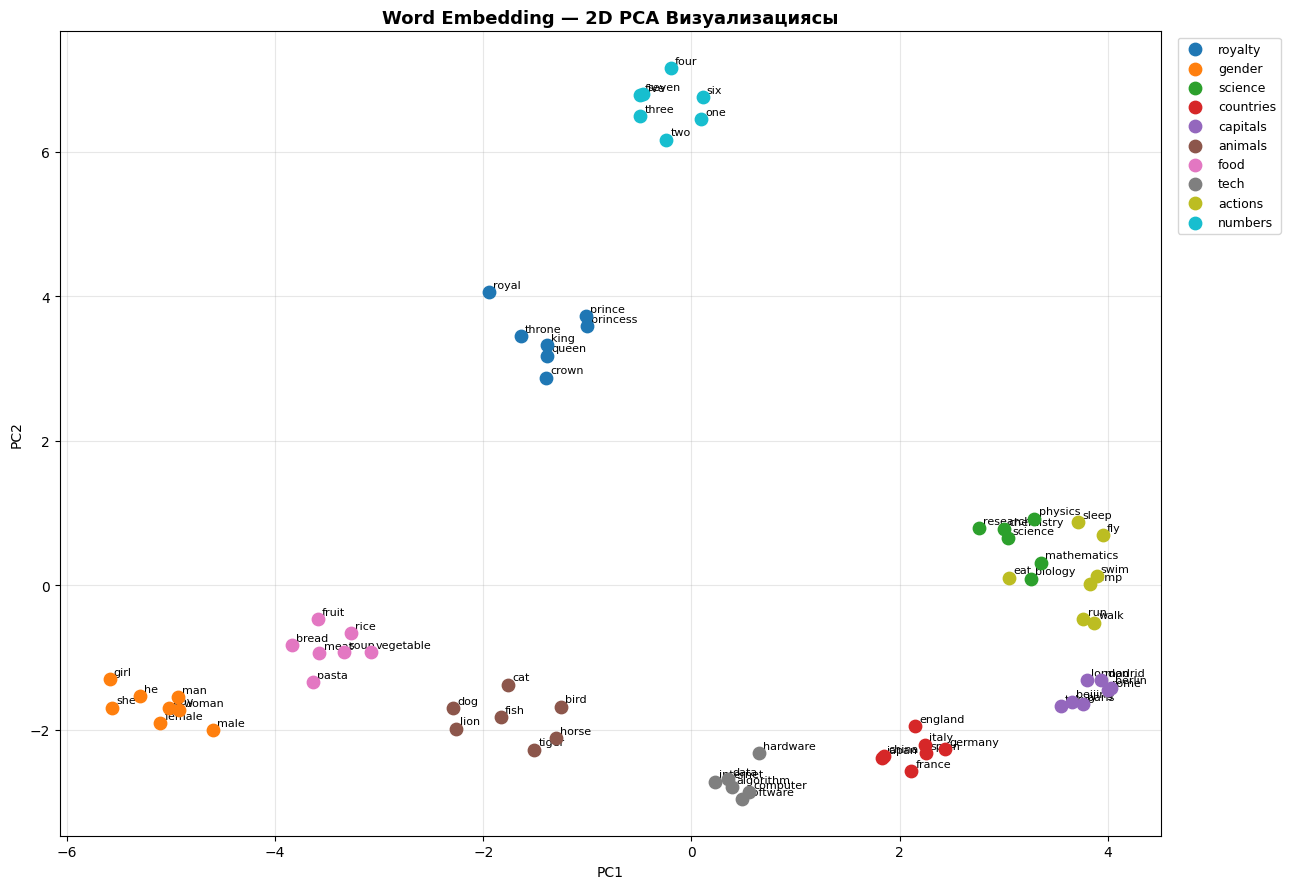

In [12]:
# Əр семантикалық топты əртүрлі рəңмен бейнелейміз
colors = plt.cm.tab10(np.linspace(0, 1, len(semantic_groups)))

fig, ax = plt.subplots(figsize=(13, 9))

for (group, group_words), color in zip(semantic_groups.items(), colors):
    for word in group_words:
        if word in word2vec:
            idx = words_list.index(word)
            x, y = vectors_2d[idx]
            ax.scatter(x, y, color=color, s=80, zorder=5)
            ax.annotate(word, (x, y), fontsize=8,
                        xytext=(3, 3), textcoords='offset points')
    # Топ белгісі
    ax.scatter([], [], color=color, label=group, s=80)

ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.set_title('Word Embedding — 2D PCA Визуализациясы', fontsize=13, fontweight='bold')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

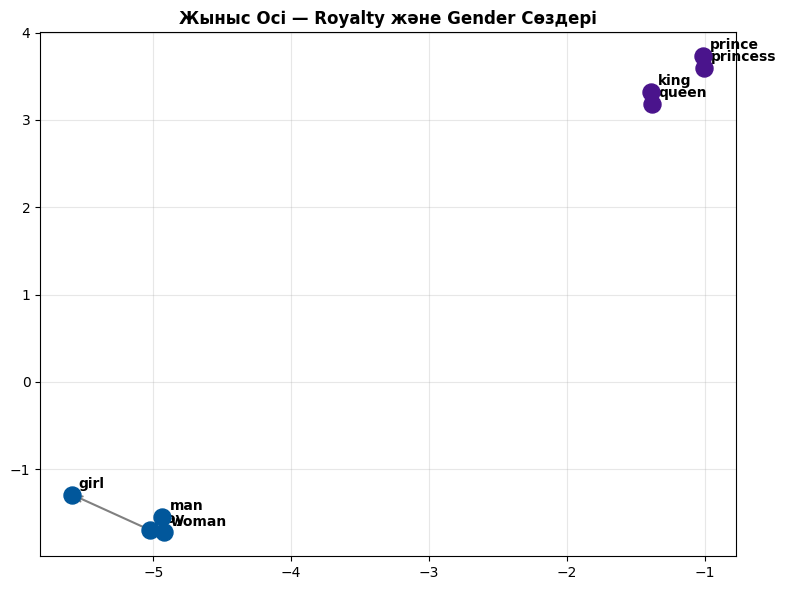

In [13]:
# ============================================================
### TODO ###
# Тек 'royalty' мен 'gender' топтарын бөлек бейнелеңіз.
# king → queen жəне man → woman байланысын plt.annotate арқылы
# көрсетіп, жебе (arrowprops) қосыңыз.
# ============================================================
focus_words = {
    'royalty': ['king', 'queen', 'prince', 'princess'],
    'gender':  ['man', 'woman', 'boy', 'girl']
}

fig, ax = plt.subplots(figsize=(8, 6))
colors_focus = {'royalty': '#4a148c', 'gender': '#01579b'}

for group, words in focus_words.items():
    for word in words:
        idx  = words_list.index(word)
        x, y = vectors_2d[idx]
        ax.scatter(x, y, color=colors_focus[group], s=150, zorder=5)
        ax.annotate(word, (x, y), fontsize=10,
                    fontweight='bold', xytext=(5, 5), textcoords='offset points')

# king → queen жебесі
arrow_pairs = [('king','queen'), ('man','woman'), ('prince','princess'), ('boy','girl')]
for w1, w2 in arrow_pairs:
    idx1, idx2 = words_list.index(w1), words_list.index(w2)
    x1, y1 = vectors_2d[idx1]
    x2, y2 = vectors_2d[idx2]
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))

ax.set_title('Жыныс Осі — Royalty жəне Gender Сөздері',
             fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6-бөлім: Ұқсастық Матрицасы

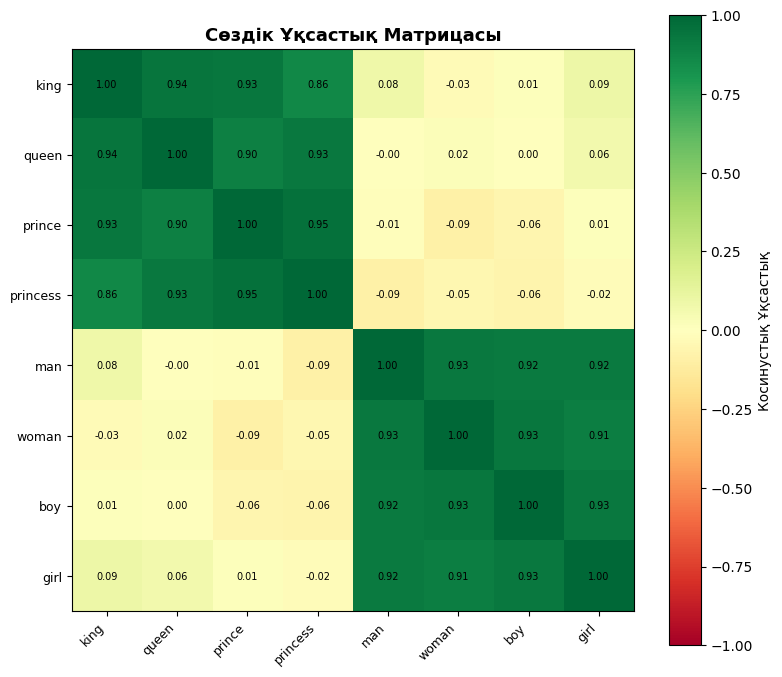

In [14]:
# ============================================================
### TODO ###
# focus_words тізімінен барлық сөздердің ұқсастық матрицасын жасаңыз.
# cosine_similarity() sklearn функциясын пайдаланыңыз.
# Нəтижені imshow() арқылы жылу картасында бейнелеңіз.
# ============================================================
all_focus = [w for words in focus_words.values() for w in words]
focus_vecs = np.array([word2vec[w] for w in all_focus])

sim_matrix = cosine_similarity(focus_vecs)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(sim_matrix, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, label='Косинустық Ұқсастық')
ax.set_xticks(range(len(all_focus)))
ax.set_yticks(range(len(all_focus)))
ax.set_xticklabels(all_focus, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(all_focus, fontsize=9)
ax.set_title('Сөздік Ұқсастық Матрицасы', fontsize=13, fontweight='bold')

# Мəндерді жаз
for i in range(len(all_focus)):
    for j in range(len(all_focus)):
        ax.text(j, i, f"{sim_matrix[i,j]:.2f}",
                ha='center', va='center', fontsize=7)

plt.tight_layout()
plt.show()

## 7-бөлім: Keras Embedding Қабаты

In [15]:
# ============================================================
### TODO ###
# Keras Embedding қабатымен жұмысты демонстрациялаңыз.
#   vocab_size=len(vocab) + 1
#   embedding_dim=EMBED_DIM
#   input_length=5
# Кездейсоқ токен тізбегін беріп, шығыс пішімін тексеріңіз.
# ============================================================
vocab_size = len(vocab) + 1

embedding_layer = layers.Embedding(
    input_dim=vocab_size,
    output_dim=EMBED_DIM,
    input_length=5
)

sample_tokens = tf.constant([[1, 5, 3, 20, 7]])
embedded_out  = embedding_layer(sample_tokens)

print(f"Кіріс пішімі:  {sample_tokens.shape}")
print(f"Шығыс пішімі: {embedded_out.shape}")
print(f"Embedding: (batch={embedded_out.shape[0]}, seq_len={embedded_out.shape[1]}, dim={embedded_out.shape[2]})")

Кіріс пішімі:  (1, 5)
Шығыс пішімі: (1, 5, 50)
Embedding: (batch=1, seq_len=5, dim=50)


In [16]:
# Алдын ала үйретілген GloVe векторларын Keras Embedding-ке жүктеу
# Бұл трансформерлерде жиі қолданылатын тəсіл

word_to_idx = {word: idx+1 for idx, word in enumerate(vocab)}

# Embedding матрицасын жасаймыз: (vocab_size, EMBED_DIM)
embedding_matrix = np.zeros((vocab_size, EMBED_DIM))
loaded = 0
for word, idx in word_to_idx.items():
    if word in word2vec:
        embedding_matrix[idx] = word2vec[word]
        loaded += 1

print(f"Embedding матрицасы пішімі: {embedding_matrix.shape}")
print(f"Жүктелген сөздер: {loaded}/{len(vocab)}")

# Keras-ке жүктейміз
pretrained_embedding = layers.Embedding(
    input_dim=vocab_size,
    output_dim=EMBED_DIM,
    weights=[embedding_matrix],
    trainable=False,   # алдын ала үйретілген — мұздатамыз
    name='glove_embedding'
)
print("Алдын ала үйретілген embedding Keras-ке жүктелді.")

Embedding матрицасы пішімі: (70, 50)
Жүктелген сөздер: 69/69
Алдын ала үйретілген embedding Keras-ке жүктелді.


## 8-бөлім: Рефлексиялық Сұрақтар

**Сұрақ 1.** BoW векторы мен Word2Vec векторының принципиалды айырмасы неде? Қайсысы `кішкентай` мен `ұсақ` сөздерін ұқсас деп таниды?

> BoW әр сөзді тәуелсіз қарастырады және семантиканы түсінбейді. Word2Vec сөздерді мағынасына қарай векторлық кеңістікте орналастырады. Сондықтан «кішкентай» мен «ұсақ» сияқты мағынасы жақын сөздерді Word2Vec ұқсас деп таниды, ал BoW оларды әртүрлі сөз ретінде көреді.

**Сұрақ 2.** Косинустық ұқсастық евклид қашықтығынан неге артық? Жоғары өлшемді кеңістікте евклид қашықтықпен қандай мəселе болады?

> Косинустық ұқсастық векторлардың бағытын салыстырады, ұзындығына тәуелді емес. Жоғары өлшемді кеңістікте евклид қашықтықтары бір-біріне өте жақын болып кетеді (curse of dimensionality), сондықтан ажырату қиындайды. Косинустық ұқсастық мұндай жағдайда тұрақтырақ нәтиже береді.

**Сұрақ 3.** Аналогия тапсырмасы `king - man + woman = queen` векторлық арифметикамен қалай жұмыс жасайды?

> Word2Vec кеңістігінде белгілі бір семантикалық қатынастар векторлық ығысулар ретінде сақталады. Сондықтан:

king−man+woman≈queen

Мұнда «ер адам → әйел адам» бағыты king сөзіне қолданылып, нәтиже queen векторына жақындайды.

**Сұрақ 4.** Word2Vec-тің негізгі кемшілігі — бір сөздің бір ғана векторы болады. `bank` (банк/жағалау) сияқты полисемиялық сөздерде бұл қандай мəселе туғызады?

> Word2Vec әр сөзге тек бір вектор береді. Сондықтан bank сөзі қаржы мекемесі мағынасында да, өзен жағасы мағынасында да қолданылса, екі мағына бір векторға араласып кетеді. Бұл көпмағыналы сөздерді өңдеуде қателіктерге әкелуі мүмкін.

**Сұрақ 5.** Embedding қабатын `trainable=False` деп мұздатқанда не болады? Қашан мұздату ыңғайлы, қашан қайта үйрету керек?

> trainable=False болғанда embedding салмақтары оқыту кезінде өзгермейді. Бұл алдын ала үйретілген білімді сақтайды және оқытуды жылдамдатады.

Мұздату тиімді:



1.   деректер аз болғанда;
2.   алдын ала үйретілген embedding сапалы болғанда.

Қайта үйрету (trainable=True) тиімді:

1.   Нүлкен арнайы домендік деректер болғанда;
2.   embedding-ті нақты тапсырмаға бейімдеу қажет болғанда.

## Қорытынды

Осы зертханада сіз косинустық ұқсастықты формула бойынша іске асырдыңыз, GloVe векторлары арқылы семантикалық ұқсас сөздерді таптыңыз, `king - man + woman = queen` аналогия тапсырмасын шешіп тексердіңіз, PCA арқылы embedding-ті 2D-де визуализациялап семантикалық топтарды байқадыңыз, жəне алдын ала үйретілген векторларды Keras Embedding-ке жүктедіңіз.

<div style="background-color:#f3e5f5; border-left:5px solid #6a1b9a; padding:12px 16px; border-radius:6px; margin-top:16px;">
<strong>Келесі қадам:</strong> Зертханалық Жұмыс 4 — BERT Embeddings: контекстке тəуелді, динамикалық сөз векторлары.
</div>